# **Joint single-cell DNA-RNA Data Processing (scONE-seq)**

## Description of Notebook

**Data: scONE-seq**    

-GEO accession GSE185269 (GSE185269-GPL18573_series_matrix.txt, GSE185269-GPL28038_series_matrix.txt)  
-SRA ID SRP339960 (many sequence read files)
  
**Table of Contents**

0. Initial Setup
1. Collect GEO GSE185269 Files
2. Collect Run Metadata for SRA SRP339960
3. Distinguish observations by DNA-seq/RNA-seq, cell origin
4. Download Relevant FASTQ Files
5.

# 0. Initial Setup

In [1]:
# Import Initial Packages
import os
import sys
import subprocess
import glob

import pandas as pd
import numpy as np

### Install Dependencies

In [2]:
# Cell 1 — Fresh runtime, run before any imports

# Step 1: Pin torch to exactly match Colab's pre-installed torchvision CUDA version
!pip install -q \
    "torch==2.10.0" \
    "torchvision==0.25.0" \
    "torchaudio==2.10.0" \
    --index-url https://download.pytorch.org/whl/cu128

# Step 2: Core numerical stack
!pip install -q \
    "numpy>=2.0,<2.1" \
    "pandas>=2.2,<3.0" \
    "scipy>=1.13,<2.0"

# Step 3: anndata + scvi + scanpy
!pip install -q \
    "anndata>=0.11,<0.12" \
    "scvi-tools>=1.2.0" \
    "scanpy>=1.10,<2.0" \
    "leidenalg"

# Step 4: Pin lightning and torchmetrics to versions compatible with torch 2.10
!pip install -q \
    "lightning>=2.4.0,<2.5.0" \
    "torchmetrics>=1.4.0,<1.5.0"

# Step 5: Genomics tools
!pip install -q \
    "snapatac2-scooby" \
    "pysam" \
    "pyranges" \
    "scrublet" \
    "gdown" \
    "pyfaidx"

# Step 6: AlphaGenome last
!pip install -q alphagenome

# Step 7: Google Cloud
!pip install -q --upgrade google-cloud-bigquery

print("Done — now do Runtime → Restart session")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.1 MB/s eta 0:00:00
  

In [3]:
# Cell 2 — version check after restart
import torch
import torchvision
import numpy as np
import anndata as ad
import scanpy as sc
#import scvi
import alphagenome

print(f"torch:       {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA match:  {torch.version.cuda}")
print(f"numpy:       {np.__version__}")
print(f"anndata:     {ad.__version__}")
print(f"scanpy:      {sc.__version__}")
#print(f"scvi:        {scvi.__version__}")
print(f"alphagenome: {alphagenome.__version__}")
print("\nAll imports successful.")

torch:       2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA match:  12.8
numpy:       2.0.2
anndata:     0.10.9
scanpy:      1.12.1
alphagenome: 0.6.1

All imports successful.


/tmp/ipykernel_7174/2352444067.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy:      {sc.__version__}")


In [ ]:
# CAN RUN WHEN TROUBLESHOOTING

# 1. Remove conflicting installs completely
# !pip uninstall -y scvi-tools scvi anndata scanpy

# 2. Clear pip cache (important)
# !pip cache purge

# 3. Reinstall compatible stack
# !pip install "anndata<0.10" "scanpy>=1.9,<1.10" "scvi-tools==1.0.4"

Found existing installation: scvi-tools 1.0.4
Uninstalling scvi-tools-1.0.4:
  Successfully uninstalled scvi-tools-1.0.4
Found existing installation: anndata 0.9.2
Uninstalling anndata-0.9.2:
  Successfully uninstalled anndata-0.9.2
Found existing installation: scanpy 1.9.8
Uninstalling scanpy-1.9.8:
  Successfully uninstalled scanpy-1.9.8
Files removed: 559
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.2/104.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.7 MB/s eta 0:00:00


### Install Entrez Direct Library

In [4]:
%%bash
set -e

# Download and install Entrez Direct into $HOME/edirect
sh -c "$(curl -fsSL https://ftp.ncbi.nlm.nih.gov/entrez/entrezdirect/install-edirect.sh)"

# Show where it was installed
ls -l $HOME/edirect


Entrez Direct has been successfully downloaded and installed.

In order to complete the configuration process, please execute the following:

  echo "export PATH=/root/edirect:\${PATH}" >> ${HOME}/.bashrc

or manually edit the PATH variable assignment in your .bashrc file.

Would you like to do that automatically now? [y/N]
Holding off, then.

To activate EDirect for this terminal session, please execute the following:

export PATH=${HOME}/edirect:${PATH}

total 32356
-rwxr-xr-x 1 3755 5333      229 Jun 24  2021 accn-at-a-time
-rwxr-xr-x 1 3755 5333     1199 Jan 25  2024 align-columns
-rwxr-xr-x 1 3755 5333      673 Jun 24  2021 amino-acid-composition
-rwxr-xr-x 1 3755 5333      216 Aug  4  2025 archive-nihocc
-rwxr-xr-x 1 3755 5333      216 Aug  4  2025 archive-nlmnlp
-rwxr-xr-x 1 3755 5333    13600 Aug  4  2025 archive-nmcds
-rwxr-xr-x 1 3755 5333      219 Jan  8 20:25 archive-peptide
-rwxr-xr-x 1 3755 5333      212 Aug  4  2025 archive-pids
-rwxr-xr-x 1 3755 5333      207 Aug  4  2

In [5]:
# Add Entrez Direct to PATH for Python Kernel
os.environ["PATH"] = os.path.join(os.environ["HOME"], "edirect") + ":" + os.environ["PATH"]
print(os.environ["PATH"])

/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [6]:
# Install NCBI Entrez Direct utilities
!apt-get install -y -qq entrez-direct

# Verify installation
!fasterq-dump --version
print(os.environ["PATH"])

!esearch -help | head -5

E: Unable to locate package entrez-direct
/bin/bash: line 1: fasterq-dump: command not found
/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin
esearch 25.4

Query Specification

  -db            Database name


### Install SRA Toolkit Library

In [7]:
%%bash
# Directly install SRA Toolkit from NCBI Server
set -e

cd $HOME
# Get latest Linux 64‑bit build (adjust URL if you need a different platform)
curl -L -o sratoolkit.tar.gz \
  https://ftp-trace.ncbi.nlm.nih.gov/sra/sdk/current/sratoolkit.current-ubuntu64.tar.gz

tar -xzf sratoolkit.tar.gz
ls

edirect
sratoolkit.3.4.1-ubuntu64
sratoolkit.tar.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 85.0M  100 85.0M    0     0  10.1M      0  0:00:08  0:00:08 --:--:-- 18.2M


In [8]:
# Add SRA Toolkit to PATH variable

home = os.environ["HOME"]
# Find the extracted sratoolkit directory
toolkits = glob.glob(os.path.join(home, "sratoolkit.*-ubuntu64"))
assert toolkits, "No sratoolkit directory found"
sra_dir = os.path.join(toolkits[0], "bin")

os.environ["PATH"] = sra_dir + ":" + os.environ["PATH"]
print(os.environ["PATH"])

/root/sratoolkit.3.4.1-ubuntu64/bin:/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [9]:
# Verify installation
!fasterq-dump --version

fasterq-dump : 3.4.1



### Connect to Google Drive

In [10]:
# CONNECT TO GOOGLE DRIVE
import google.colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load files from Google Cloud BigQuery (optional)

# Authenticate Session
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

# Set up GCP Project
#project_id = 'bmi-702-project' # Replace with your actual project ID
#from google.cloud import bigquery
#client = bigquery.Client(project=project_id)

Authenticated


# 1. Collect GEO GSE185269 Files

## 1a. Download GEO Data to Google Drive

In [ ]:
# Download processed data (countmatrices) from GEO Project
# Claude suggested code
import subprocess

# Define output directory
output_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files"
os.makedirs(output_dir, exist_ok=True)

# Download GEO supplementary files directly via FTP
geo_base = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE185nnn/GSE185269/suppl/"

# List available supplementary files
print("Available files:")
!curl -s {geo_base} | grep -oP '(?<=href=")[^"]+\.gz'

# Download all .gz supplementary files to the output directory
!wget -r -nd -np -A "*.gz" -P "{output_dir}" {geo_base}

# Verify download
!ls -lh "{output_dir}"

Available files:
GSE185269_10x_GBM_Gene_UMI_counts_matrix.csv.gz
GSE185269_10x_GBM_annotation.csv.gz
GSE185269_Bulk_benchmark_WGS_NormalizedCounts.txt.gz
GSE185269_Bulk_benchmark_WGS_RawCounts.txt.gz
GSE185269_Smartseq2_HCT116_RNA_gene_counts_matrix.csv.gz
GSE185269_Smartseq2_PBMC_RNA_gene_counts_matrix.csv.gz
GSE185269_scONE_HCT116_nuclei_gene_counts_expr.csv.gz
GSE185269_scONE_HCT116_whole_gene_counts_expr.csv.gz
GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz
GSE185269_scONEseq_Cellline_scWGS_normalized_counts_matrix.txt.gz
GSE185269_scONEseq_GBM_RNA_gene_counts_matrix.csv.gz
GSE185269_scONEseq_GBM_sample_annotation.csv.gz
GSE185269_scONEseq_GBM_scWGS_mBAF_matrix.txt.gz
GSE185269_scONEseq_GBM_scWGS_normalized_counts_matrix.txt.gz
GSE185269_scONEseq_PBMC_RNA_gene_counts_matrix.csv.gz
--2026-04-20 14:47:25--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE185nnn/GSE185269/suppl/
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 2607:f220:41e:

## 1b. Read in GEO Series Matrices

In [ ]:
# Folder and file paths
folder_path = '/content/drive/MyDrive/MIT HST 506/scONEseq_data'
GEO_metadata_path_1 = '/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269-GPL18573_series_matrix_edited.txt'
GEO_metadata_path_2 = '/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269-GPL28038_series_matrix_edited.txt'

GEO_series_matrix_1 = (pd.read_table(GEO_metadata_path_1)).transpose()
GEO_series_matrix_2 = (pd.read_table(GEO_metadata_path_2)).transpose()

# Make first row the column names
GEO_series_matrix_1.columns = GEO_series_matrix_1.iloc[0]
GEO_series_matrix_1.drop(GEO_series_matrix_1.index[0], inplace=True)

GEO_series_matrix_2.columns = GEO_series_matrix_2.iloc[0]
GEO_series_matrix_2.drop(GEO_series_matrix_2.index[0], inplace=True)

In [ ]:
(GEO_series_matrix_2).head()

Sample_title,Sample_geo_accession,Sample_status,Sample_submission_date,Sample_last_update_date,Sample_type,Sample_channel_count,Sample_source_name_ch1,Sample_organism_ch1,Sample_characteristics_ch1,Sample_characteristics_ch1,...,Sample_instrument_model,Sample_library_selection,Sample_library_source,Sample_library_strategy,Sample_relation,Sample_relation,Sample_supplementary_file_1,series_matrix_table_begin,ID_REF,series_matrix_table_end
"HCT116, live whole cell, cell 001",GSM6682926,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682926,NaN
"HCT116, live whole cell, cell 002",GSM6682928,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682928,NaN
"HCT116, live whole cell, cell 003",GSM6682929,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682929,NaN
"HCT116, live whole cell, cell 004",GSM6682930,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682930,NaN
"HCT116, live whole cell, cell 005",GSM6682931,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682931,NaN


## 1c. Read in GEO Processed Count Matrices

In [ ]:
Cellline_RNA_gene_counts = pd.read_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz", compression="gzip")
# Size: 56594 rows × 336 columns
# UMI counts or read counts per gene per cell

Cellline_scWGS_normalized_counts = pd.read_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_scWGS_normalized_counts_matrix.txt", sep = "\t")
# Size: 5393 rows × 216 columns
# Can treat each row as a genomic tract (bin/segment) and each column as a cell’s DNA profile.

In [ ]:
(Cellline_scWGS_normalized_counts.columns)

Index(['CHR', 'START', 'END', 'feature', 'One.HUVEC.01_dedup',
       'One.HUVEC.02_dedup', 'One.HUVEC.04_dedup', 'One.HUVEC.14_dedup',
       'One.HUVEC.18_dedup', 'One.HUVEC.19_dedup',
       ...
       'C2.NPC.10H_dedup', 'C2.NPC.11B_dedup', 'C2.NPC.11C_dedup',
       'C2.NPC.11E_dedup', 'C2.NPC.11F_dedup', 'C2.NPC.11G_dedup',
       'C2.NPC.11H_dedup', 'C2.NPC.12B_dedup', 'C2.NPC.12F_dedup',
       'C2.NPC.12G_dedup'],
      dtype='object', length=216)

# 2. Collect the Run Metadata for SRA SRP339960

## 2a. Fetch the SRA metadata

In [ ]:
items = os.listdir('/content/drive/MyDrive/MIT HST 506/scONEseq_data/SRA_SRP339960_files')
print(items)

['.DS_Store', 'SRP339960_runinfo_original.csv', 'SRP339960_runinfo.csv']


In [ ]:
# Fetch the Run Metadata for SRP339960 study (method using Entrez commands)

# !esearch -db sra -query SRP339960 | efetch -format runinfo > /content/drive/MyDrive/"MIT HST 506"/scONEseq_data/SRA_SRP339960_files/SRP339960_runinfo.csv

## 2b. Load the SRA metadata

In [ ]:
# Folder and file paths
folder_path = '/content/drive/MyDrive/MIT HST 506/scONEseq_data'
SRA_metadata_path = '/content/drive/MyDrive/MIT HST 506/scONEseq_data/SRA_SRP339960_files/SRP339960_runinfo.csv'

SRA_metadata = pd.read_csv(SRA_metadata_path)

In [ ]:
(SRA_metadata).head()

,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Affection_Status,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash
0,SRR16195160,2022-12-31 00:17:52,2021-10-04 17:05:27,442928,63422994,442928,143,24,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,7F5445FC0D80D205A571A73A84A9813E,4624C3F8688710092CB2E423492A75BB
1,SRR16195159,2022-12-31 00:17:52,2021-10-04 17:05:27,289373,41434581,289373,143,16,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,3068B3F5E9C0C2F9A3A972C5C4889108,D629EB7BAA322A8F5F0350F4B06C4896
2,SRR16195158,2022-12-31 00:17:52,2021-10-04 17:05:28,330976,47390825,330976,143,18,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,60F618611CE76F02E8C973729976403F,55E10B7273275C5C5823327EE077CD98
3,SRR16195157,2022-12-31 00:17:52,2021-10-04 17:05:44,1433760,205376026,1433760,143,82,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D152661CFEAA7B2875DAC9D5CF5E706E,27458B2217D5EA134A6F093CC0330A1F
4,SRR16195156,2022-12-31 00:17:52,2021-10-04 17:05:46,1249934,179029075,1249934,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D8755140C9235842B99A1295DAEE5CAC,9C8F0FA05CE1662288524F1170EB7260


In [ ]:
# Load and inspect

runinfo = pd.read_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/SRA_SRP339960_files/SRP339960_runinfo.csv")
print(runinfo.shape)
print(runinfo.columns.tolist())
runinfo.head(10)

(621, 47)
['Run', 'ReleaseDate', 'LoadDate', 'spots', 'bases', 'spots_with_mates', 'avgLength', 'size_MB', 'AssemblyName', 'download_path', 'Experiment', 'LibraryName', 'LibraryStrategy', 'LibrarySelection', 'LibrarySource', 'LibraryLayout', 'InsertSize', 'InsertDev', 'Platform', 'Model', 'SRAStudy', 'BioProject', 'Study_Pubmed_id', 'ProjectID', 'Sample', 'BioSample', 'SampleType', 'TaxID', 'ScientificName', 'SampleName', 'g1k_pop_code', 'source', 'g1k_analysis_group', 'Subject_ID', 'Sex', 'Disease', 'Tumor', 'Affection_Status', 'Analyte_Type', 'Histological_Type', 'Body_Site', 'CenterName', 'Submission', 'dbgap_study_accession', 'Consent', 'RunHash', 'ReadHash']


,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Affection_Status,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash
0,SRR16195160,2022-12-31 00:17:52,2021-10-04 17:05:27,442928,63422994,442928,143,24,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,7F5445FC0D80D205A571A73A84A9813E,4624C3F8688710092CB2E423492A75BB
1,SRR16195159,2022-12-31 00:17:52,2021-10-04 17:05:27,289373,41434581,289373,143,16,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,3068B3F5E9C0C2F9A3A972C5C4889108,D629EB7BAA322A8F5F0350F4B06C4896
2,SRR16195158,2022-12-31 00:17:52,2021-10-04 17:05:28,330976,47390825,330976,143,18,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,60F618611CE76F02E8C973729976403F,55E10B7273275C5C5823327EE077CD98
3,SRR16195157,2022-12-31 00:17:52,2021-10-04 17:05:44,1433760,205376026,1433760,143,82,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D152661CFEAA7B2875DAC9D5CF5E706E,27458B2217D5EA134A6F093CC0330A1F
4,SRR16195156,2022-12-31 00:17:52,2021-10-04 17:05:46,1249934,179029075,1249934,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D8755140C9235842B99A1295DAEE5CAC,9C8F0FA05CE1662288524F1170EB7260
5,SRR16195155,2022-12-31 00:17:52,2021-10-04 17:05:48,1249873,179028128,1249873,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,A030D8031AD0F81019F804F0DDBFC276,48036FDD9DC94429BC9BDA44B2A4ED3C
6,SRR16195154,2022-12-31 00:17:52,2021-10-04 17:05:45,1229207,176079810,1229207,143,70,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,E475C90208DE4129E051CF73D9EAFA98,2A7F69DBCE6B811F488FD7450B0D53C6
7,SRR16195153,2022-12-31 00:17:52,2021-10-04 17:05:41,1024753,146792703,1024753,143,59,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,67DA2996604182344AD26D7EE1AF14B5,5FAA152A579A111C612A94EFD9F3606A
8,SRR16195152,2022-12-31 00:17:52,2021-10-04 17:05:36,1015576,145446512,1015576,143,58,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,CF0AEF250FF730207A569BF366135B43,0C2F1867F5C907379937020DB94ABDFA
9,SRR16195151,2022-12-31 00:17:52,2021-10-04 17:05:36,713817,102235095,713817,143,41,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,263EBD86D10A955037FE225C970E5AB5,E72940FD9479ABFBDC9A96D6E4B8E0F2


# 3. Distinguish observations by DNA-seq/RNA-seq, cell origin

## 3a. Separate scDNA and scRNA Runs

In [ ]:
# Separate WGS (DNA) and RNA-seq runs
dna_runs = runinfo[runinfo['LibraryStrategy'] == 'OTHER']['Run'].tolist()
rna_runs = runinfo[runinfo['LibraryStrategy'] == 'RNA-Seq']['Run'].tolist()

print(f"DNA (WGS) runs: {len(dna_runs)}")
print(f"RNA-seq runs:   {len(rna_runs)}")
print("\nDNA runs:", dna_runs[:5])
print("RNA runs:", rna_runs[:5])

DNA (WGS) runs: 525
RNA-seq runs:   96

DNA runs: ['SRR16195157', 'SRR16195156', 'SRR16195155', 'SRR16195154', 'SRR16195153']
RNA runs: ['SRR16195160', 'SRR16195159', 'SRR16195158', 'SRR16195109', 'SRR16195108']


In [ ]:
# Sample Name, Library Name, BioSample
print(f"Number of unique Runs: {len((runinfo['Run']).unique())}") #621
print(f"Number of unique Sample Names: {len((runinfo['SampleName']).unique())}") #621
print(f"Number of unique Library Names: {len((runinfo['LibraryName']).unique())}") #621
print(f"Number of unique BioSamples: {len((runinfo['BioSample']).unique())}") #621
print(f"Number of unique Experiments: {len((runinfo['Experiment']).unique())}") #621
print(f"Number of unique Samples: {len((runinfo['Sample']).unique())}") #621


Number of unique Runs: 621
Number of unique Sample Names: 621
Number of unique Library Names: 621
Number of unique BioSamples: 621
Number of unique Experiments: 621
Number of unique Samples: 621


In [ ]:
dna_len = len(dna_runs)        # 525
rna_len = len(rna_runs)        # 96

# Pad rna_runs with NaN up to dna_len
rna_runs_padded = rna_runs + [np.nan] * (dna_len - rna_len)

In [ ]:
len(rna_runs_padded)

525

In [ ]:

df_runs = pd.DataFrame({
    "DNA_Samples": dna_runs,
    "RNA_Samples": rna_runs_padded
})

df_runs.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_RNA_samples.csv")

## 3b. Preprocess GEO Series Matrix 1 (GPL18573)

In [ ]:
GEO_series_matrix_1_processed = GEO_series_matrix_1.copy() #431 x 48
# IDEA: join SRA metadata and GEO series matrix 1 on their unique SampleName/Sample_geo_accession.

# Rename duplicate columns
from collections import Counter

cols = list(GEO_series_matrix_1_processed.columns)
seen = Counter()
new_cols = []

# keep the first column name exactly
new_cols.append(cols[0])
seen[cols[0]] += 1

# process the rest, de‑duplicating as needed
for c in cols[1:]:
    seen[c] += 1
    if seen[c] == 1:
        new_cols.append(c)
    else:
        new_cols.append(f"{c}_{seen[c]}")

GEO_series_matrix_1_processed.columns = new_cols

GEO_series_matrix_1_processed.index.name = 'Sample_title'
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.reset_index()

In [ ]:
# GEO series matrix 1: 431 rows x 49 columns

# Variables to keep:
# Sample_title, Sample_geo_accession, Sample_source_name_ch1, Sample_library_selection, Sample_library_source
# Sample_library_strategy, Sample_characteristics_ch1_2, Sample_description, Sample_description_2, Sample_platform_id
# Sample_instrument_model,

# Variables to remove:
# Sample_status, Sample_submission_date, Sample_last_update, Sample_type, Sample_channel_count
# Sample_organism_ch1, Sample_characteristics_ch1, Sample_instrument_model, Sample_relation, Sample_relation_2
# Sample_supplementary_file_1, series_matrix_table_begin, ID_REF, series_matrix_table_end
# Sample_characteristics_ch1_2, Sample_growth_protocol_ch1, Sample_molecule_ch1, Sample_extract_protocol_ch1,
# Sample_extract_protocol_ch1_2, Sample_taxid_ch1
# 'Sample_data_processing', 'Sample_data_processing_2', 'Sample_data_processing_3', 'Sample_data_processing_4', 'Sample_data_processing_5',
# 'Sample_data_processing_6','Sample_data_processing_7', 'Sample_data_processing_8', 'Sample_data_processing_9', 'Sample_data_processing_10',
# 'Sample_contact_name', 'Sample_contact_email', 'Sample_contact_laboratory', 'Sample_contact_department', 'Sample_contact_institute',
# 'Sample_contact_address','Sample_contact_city', 'Sample_contact_zip/postal_code', 'Sample_contact_country', 'Sample_data_row_count',

vars_to_keep = [
"Sample_title", "Sample_geo_accession", "Sample_source_name_ch1", "Sample_library_selection",
"Sample_library_source", "Sample_library_strategy", "Sample_characteristics_ch1_2", "Sample_description",
 "Sample_description_2", "Sample_platform_id", "Sample_instrument_model"
]

GEO_series_matrix_1_processed = GEO_series_matrix_1_processed[vars_to_keep]

In [ ]:
# Fix sample_description column
GEO_series_matrix_1_processed["Sample_description"] = GEO_series_matrix_1_processed["Sample_description"].replace("RNA+DNA", np.nan)

# New column with the cell info from whichever column is non‑NaN
GEO_series_matrix_1_processed["Sample_description"] = GEO_series_matrix_1_processed["Sample_description"].fillna(
    GEO_series_matrix_1_processed["Sample_description_2"]
)

# Remove unnecessary columns
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.drop(columns=["Sample_description_2"])

# (GEO_series_matrix_1_processed["Sample_characteristics_ch1_2"]) #431 unique values

In [ ]:
GEO_series_matrix_1_processed.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GSE185269-GPL18573_series_matrix_processed.csv")

## 3c. Preprocess GEO Series Matrix 2 (GPL18573)

In [ ]:
# GEO series matrix 2: 47 columns
GEO_series_matrix_2_processed = GEO_series_matrix_2.copy()

# Rename duplicate columns
from collections import Counter

cols = list(GEO_series_matrix_2_processed.columns)
seen = Counter()
new_cols = []

# keep the first column name exactly
new_cols.append(cols[0])
seen[cols[0]] += 1

# process the rest, de‑duplicating as needed
for c in cols[1:]:
    seen[c] += 1
    if seen[c] == 1:
        new_cols.append(c)
    else:
        new_cols.append(f"{c}_{seen[c]}")

GEO_series_matrix_2_processed.columns = new_cols

GEO_series_matrix_2_processed.index.name = 'Sample_title'
GEO_series_matrix_2_processed = GEO_series_matrix_2_processed.reset_index()

In [ ]:
# GEO series matrix 2: #190 rows x 47 columns

# Variables to keep:
# Sample_title, Sample_geo_accession, Sample_characteristics_ch1_2, Sample_description, Sample_platform_id
# Sample_library_selection, Sample_library_source, Sample_library_strategy, Sample_instrument_model


# Variables to remove:
# Sample_status, Sample_submission_date, Sample_last_update, Sample_type, Sample_channel_count
# Sample_organism_ch1, Sample_characteristics_ch1, Sample_instrument_model, Sample_relation, Sample_relation_2
# Sample_supplementary_file_1, series_matrix_table_begin, ID_REF, series_matrix_table_end
# Sample_growth_protocol_ch1, Sample_molecule_ch1, Sample_extract_protocol_ch1,
# Sample_extract_protocol_ch1_2, Sample_taxid_ch1, Sample_molecule_ch1, Sample_source_name_ch1
# 'Sample_data_processing', 'Sample_data_processing_2', 'Sample_data_processing_3', 'Sample_data_processing_4', 'Sample_data_processing_5',
# 'Sample_data_processing_6','Sample_data_processing_7', 'Sample_data_processing_8', 'Sample_data_processing_9', 'Sample_data_processing_10',
# 'Sample_contact_name', 'Sample_contact_email', 'Sample_contact_laboratory', 'Sample_contact_department', 'Sample_contact_institute',
# 'Sample_contact_address','Sample_contact_city', 'Sample_contact_zip/postal_code', 'Sample_contact_country', 'Sample_data_row_count',


vars_to_keep_2 = [
"Sample_title", "Sample_geo_accession", "Sample_characteristics_ch1_2", "Sample_description", "Sample_platform_id",
"Sample_library_selection", "Sample_library_source", "Sample_library_strategy", "Sample_instrument_model"
]

GEO_series_matrix_2_processed = GEO_series_matrix_2_processed[vars_to_keep_2]

GEO_series_matrix_2_processed["Sample_description"] = GEO_series_matrix_2_processed["Sample_title"]

# GEO_series_matrix_2_processed.head(5)

In [ ]:
GEO_series_matrix_2_processed.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GSE185269-GPL28038_series_matrix_processed.csv")

## 3d. Concatenate GEO Series Matrices

In [ ]:
#GEO_series_matrix_1_processed.head()

# Rename Sample_source_name_ch1 to Sample_cell_line
GEO_series_matrix_1_processed.rename(columns={'Sample_source_name_ch1': 'Sample_cell_line'}, inplace=True)

# Rename Sample_description to Sample_cell_description
GEO_series_matrix_1_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)

# Remove Sample_characteristics_ch1_2
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.drop(columns=["Sample_characteristics_ch1_2"])

,Sample_title,Sample_geo_accession,Sample_cell_line,Sample_library_selection,Sample_library_source,Sample_library_strategy,Sample_cell_description,Sample_platform_id,Sample_instrument_model
0,Smart-HCT-01,GSM5609425,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 001,GPL18573,Illumina NextSeq 500
1,Smart-HCT-02,GSM5609426,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 002,GPL18573,Illumina NextSeq 500
2,Smart-HCT-03,GSM5609427,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 003,GPL18573,Illumina NextSeq 500
3,Smart-HCT-04,GSM5609428,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 004,GPL18573,Illumina NextSeq 500
4,Smart-HCT-05,GSM5609429,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 005,GPL18573,Illumina NextSeq 500
...,...,...,...,...,...,...,...,...,...
426,NPC43 scONEseq 166,GSM5609851,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 166,GPL18573,Illumina NextSeq 500
427,NPC43 scONEseq 167,GSM5609852,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 167,GPL18573,Illumina NextSeq 500
428,NPC43 scONEseq 168,GSM5609853,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 168,GPL18573,Illumina NextSeq 500
429,NPC43 scONEseq 169,GSM5609854,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 169,GPL18573,Illumina NextSeq 500


In [ ]:
# Rename Sample_characteristics_ch1_2 to Sample_cell_line
GEO_series_matrix_2_processed.rename(columns={'Sample_characteristics_ch1_2': 'Sample_cell_line'}, inplace=True)

# Rename Sample_description to Sample_cell_description
GEO_series_matrix_2_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)


/tmp/ipykernel_1516/2529234801.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GEO_series_matrix_2_processed.rename(columns={'Sample_characteristics_ch1_2': 'Sample_cell_line'}, inplace=True)
/tmp/ipykernel_1516/2529234801.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GEO_series_matrix_2_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)


In [ ]:
GEO_series_matrix_combined = pd.concat([GEO_series_matrix_1_processed, GEO_series_matrix_2_processed], ignore_index = True)
GEO_series_matrix_combined.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_series_matrix_combined.csv")


## 3e. Join GEO series metadata with SRA Metadata

In [ ]:
# New df name: full_metadata
# Join runinfo and GEO_series_matrix_combined: runinfo["SampleName"] and GEO_series_matrix_combined["Sample_geo_accession"]
# Use left merge to join matrices
#GEO_series_matrix_combined["Sample_geo_accession"]

geo_meta = GEO_series_matrix_combined.rename(
    columns={"Sample_geo_accession": "SampleName"}
)

full_metadata = runinfo.merge(
geo_meta,
on = "SampleName",
how = "left"
)

full_metadata.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/full_metadata.csv") # 621 rows × 55 columns


In [ ]:
cols = ["Run", "LibraryName", "LibraryStrategy", "LibrarySelection", "SampleName", "Sample_title", "Sample_cell_line", "Sample_library_selection", "Sample_library_source", "Sample_library_strategy", "Sample_cell_description", "Sample_platform_id", "Sample_instrument_model"]


metadata_subset = full_metadata[cols]

metadata_subset.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/metadata_subset.csv")


In [ ]:
full_metadata = pd.read_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/full_metadata.csv")

full_metadata

,Unnamed: 0,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,...,RunHash,ReadHash,Sample_title,Sample_cell_line,Sample_library_selection,Sample_library_source,Sample_library_strategy,Sample_cell_description,Sample_platform_id,Sample_instrument_model
0,0,SRR16195160,2022-12-31 00:17:52,2021-10-04 17:05:27,442928,63422994,442928,143,24,NaN,...,7F5445FC0D80D205A571A73A84A9813E,4624C3F8688710092CB2E423492A75BB,Smart-HCT-01,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 001,GPL18573,Illumina NextSeq 500
1,1,SRR16195159,2022-12-31 00:17:52,2021-10-04 17:05:27,289373,41434581,289373,143,16,NaN,...,3068B3F5E9C0C2F9A3A972C5C4889108,D629EB7BAA322A8F5F0350F4B06C4896,Smart-HCT-02,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 002,GPL18573,Illumina NextSeq 500
2,2,SRR16195158,2022-12-31 00:17:52,2021-10-04 17:05:28,330976,47390825,330976,143,18,NaN,...,60F618611CE76F02E8C973729976403F,55E10B7273275C5C5823327EE077CD98,Smart-HCT-03,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 003,GPL18573,Illumina NextSeq 500
3,3,SRR16195157,2022-12-31 00:17:52,2021-10-04 17:05:44,1433760,205376026,1433760,143,82,NaN,...,D152661CFEAA7B2875DAC9D5CF5E706E,27458B2217D5EA134A6F093CC0330A1F,HUVEC+H9 scONEseq 002,HUVEC+H9 cell line co-culture,other,transcriptomic,OTHER,Normal single cell 002,GPL18573,Illumina NextSeq 500
4,4,SRR16195156,2022-12-31 00:17:52,2021-10-04 17:05:46,1249934,179029075,1249934,143,72,NaN,...,D8755140C9235842B99A1295DAEE5CAC,9C8F0FA05CE1662288524F1170EB7260,HUVEC+H9 scONEseq 003,HUVEC+H9 cell line co-culture,other,transcriptomic,OTHER,Normal single cell 003,GPL18573,Illumina NextSeq 500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,616,SRR22047390,2022-12-31 00:27:08,2022-10-26 17:15:29,2550625,504658501,2550625,197,319,NaN,...,948DAC8C3135350923499899C16656CA,29338FA2DCB2E903E7121C7AC6E9E3A1,"HCT116, extracted nuclei, cell 094",cell line: HCT-116,other,transcriptomic,OTHER,"HCT116, extracted nuclei, cell 094",GPL28038,DNBSEQ-G400
617,617,SRR22047389,2022-12-31 00:27:08,2022-10-26 17:14:07,1414229,279796760,1414229,197,179,NaN,...,55F56CB571D597819D948233CF7B7788,1742E9ED5C87FAC2E089C5286F7B4DA3,"HCT116, extracted nuclei, cell 095",cell line: HCT-116,other,transcriptomic,OTHER,"HCT116, extracted nuclei, cell 095",GPL28038,DNBSEQ-G400
618,618,SRR22047388,2022-12-31 00:27:08,2022-10-26 17:18:55,2265674,448248453,2265674,197,286,NaN,...,91E7839736663CDBA7B278A3A3132330,2E2E96B41B40D4EB80CFE19C180F3CBC,"HCT116, extracted nuclei, cell 096",cell line: HCT-116,other,transcriptomic,OTHER,"HCT116, extracted nuclei, cell 096",GPL28038,DNBSEQ-G400
619,619,SRR22047387,2022-12-31 00:27:08,2022-10-26 17:14:48,2637053,521739836,2637053,197,330,NaN,...,5BC6857FC0AB12392E9D76944613172F,BB792EEA35690A72EC725FBD0FABA2FA,"HCT116, extracted nuclei, cell 097",cell line: HCT-116,other,transcriptomic,OTHER,"HCT116, extracted nuclei, cell 097",GPL28038,DNBSEQ-G400


## 3f. Label runs by RNA/DNA sequencing and cell number

In [ ]:
df = full_metadata.copy()

# For convenience, give it a short name
df["cell_id"] = df["Sample_cell_description"].str.strip()

In [ ]:
# Identify RNA vs DNA rows
rna = df[df["LibraryStrategy"] == "RNA-Seq"].copy()
dna = df[df["LibraryStrategy"] != "RNA-Seq"].copy()

#rna["Sample_title"].value_counts()
#dna["Sample_title"].value_counts()
#rna["Sample_platform_id"].value_counts()
#dna["Sample_platform_id"].value_counts()

In [ ]:

#df["cell_id"].unique()
#with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
#    print(df.loc[:,["cell_id", "LibraryStrategy", "Sample_platform_id"]])

#print(df["LibraryStrategy"])

In [ ]:
# Normalize biological cells with different strings; focus on HCT116 first

# Pull HCT116 rows:
hct = df[df["Sample_cell_description"].str.contains("HCT116", na=False)].copy()

# Extract a normalized cell number
import re

def extract_cell_num(desc):
    if pd.isna(desc):
        return None
    m = re.search(r'(\d+)\s*$', desc)  # last integer at end of string
    return int(m.group(1)) if m else None

hct["cell_num"] = hct["Sample_cell_description"].apply(extract_cell_num)


# RNA: Smart-Seq
hct_rna = hct[hct["LibraryStrategy"] == "RNA-Seq"].copy()

# DNA: scONE on DNBSEQ (GPL28038)
hct_dna = hct[(hct["LibraryStrategy"] != "RNA-Seq") &
              (hct["Sample_platform_id"] == "GPL28038")].copy()

In [ ]:
# Split DNA into live whole cell and extracted nuclei
dna_live   = hct_dna[hct_dna["Sample_cell_description"].str.contains("live whole cell", na=False)].copy()
dna_nuclei = hct_dna[hct_dna["Sample_cell_description"].str.contains("extracted nuclei", na=False)].copy()

# Make a preferred DNA table: live whole cell first, then nuclei as fallback
# one DNA run per (cell_num, type)
dna_live_min = dna_live.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "dna_run_live"})
dna_nuclei_min = dna_nuclei.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "dna_run_nuclei"})

# Merge them
dna_pref = pd.merge(dna_live_min, dna_nuclei_min, on="cell_num", how="outer")

# Select a single DNA run per cell_num
def choose_dna(row):
    if pd.notna(row["dna_run_live"]):
        return row["dna_run_live"]
    else:
        return row["dna_run_nuclei"]

dna_pref["dna_run"] = dna_pref.apply(choose_dna, axis=1)

# Keep only rows where we have some DNA
dna_pref = dna_pref[pd.notna(dna_pref["dna_run"])]
dna_pref = dna_pref[["cell_num", "dna_run"]]

In [ ]:
# Build combined RNA-DNA table
rna_min = hct_rna.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "rna_run"})

pairs = pd.merge(rna_min, dna_pref, on="cell_num", how="inner")

#96 pairs
#len(pairs)

pairs.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_RNA_pairs.csv")


In [ ]:
# Build combined RNA-DNA table, only include DNA from live whole cells
dna_only_live = dna_live_min.rename(columns={"Run": "dna_run"})
pairs_live = pd.merge(rna_min, dna_only_live, on="cell_num", how="inner")

#type(pairs_live) #92
pairs_live.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_RNA_pairs_live_whole_cell.csv")

# 4. Download FASTQ Files

## 4a. Download a small subset first to test

In [ ]:
# Define base path on Google Drive
base_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files"

os.makedirs(f"{base_path}/dna", exist_ok=True)
os.makedirs(f"{base_path}/rna", exist_ok=True)

# Test with first DNA run
test_dna = dna_runs[0]
!fasterq-dump {test_dna} --split-files --outdir "{base_path}/dna" --threads 4
!gzip "{base_path}/dna/{test_dna}"*.fastq

# Test with first RNA run
test_rna = rna_runs[0]
!fasterq-dump {test_rna} --split-files --outdir "{base_path}/rna" --threads 4
!gzip "{base_path}/rna/{test_rna}"*.fastq

!ls -lh "{base_path}/dna/"
!ls -lh "{base_path}/rna/"

spots read      : 1,433,760
reads read      : 2,867,520
reads written   : 2,867,520
spots read      : 442,928
reads read      : 885,856
reads written   : 885,856
total 127M
-rw------- 1 root root 64M Apr 20 03:06 SRR16195157_1.fastq.gz
-rw------- 1 root root 63M Apr 20 03:06 SRR16195157_2.fastq.gz
total 40M
-rw------- 1 root root 20M Apr 20 03:07 SRR16195160_1.fastq.gz
-rw------- 1 root root 20M Apr 20 03:07 SRR16195160_2.fastq.gz


In [ ]:
# Download DNA runs from joint DNA-RNA csv file

# Define base path on Google Drive
base_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files"

paired_data = pd.read_csv(("/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_RNA_pairs.csv"))
dna_run_list = paired_data["dna_run"].to_list()
dna_run_list_1_10 = dna_run_list[1:10]

for run in dna_run_list:
    !fasterq-dump {run} --split-files --outdir "{base_path}/dna" --threads 4
    !gzip "{base_path}/dna/{run}"*.fastq

In [ ]:
dna_run_list_1_10

In [ ]:
for run in dna_run_list:
    !fasterq-dump {run} --split-files --outdir "{base_path}/dna" --threads 4
    !gzip "{base_path}/dna/{run}"*.fastq


# 5. Generate Cell Type-Specific RNA-seq Embeddings using scVI

## 5a. Quality Control and Preprocessing of scRNA-seq

In [ ]:
# LIST FILES IN DIRECTORY
geo_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files"
for f in sorted(os.listdir(geo_dir)):
    size = os.path.getsize(os.path.join(geo_dir, f))
    print(f"{f:60s}  {size/1024:.1f} KB")

.DS_Store                                                     8.0 KB
GSE185269-GPL18573_series_matrix.txt                          917.6 KB
GSE185269-GPL18573_series_matrix.txt.gz                       17.3 KB
GSE185269-GPL18573_series_matrix_edited.txt                   869.8 KB
GSE185269-GPL18573_series_matrix_processed.csv                62.9 KB
GSE185269-GPL28038_series_matrix.txt                          245.2 KB
GSE185269-GPL28038_series_matrix.txt.gz                       8.0 KB
GSE185269-GPL28038_series_matrix_edited.txt                   226.3 KB
GSE185269-GPL28038_series_matrix_processed.csv                28.9 KB
GSE185269_family.soft                                         1827.8 KB
GSE185269_family.soft.gz                                      30.3 KB
GSE185269_family.xml                                          1749.0 KB
GSE185269_family.xml.tgz                                      27.5 KB
GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv        93610.0 KB
GSE185269_s

In [ ]:
# GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz
# Load and uncompress CSV object
csv_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz"
df = pd.read_csv(csv_path, index_col=0, compression = "gzip") # Size: 56594 x 335

In [ ]:
col_list = (df.columns)
(col_list)

Index(['One.HCT.01', 'One.HCT.02', 'One.HCT.03', 'One.HCT.04', 'One.HCT.05',
       'One.HCT.06', 'One.HCT.07', 'One.HCT.08', 'One.HCT.09', 'One.HCT.10',
       ...
       'C2.NPC.11C', 'C2.NPC.11E', 'C2.NPC.11F', 'C2.NPC.11G', 'C2.NPC.11H',
       'C2.NPC.12B', 'C2.NPC.12C', 'C2.NPC.12E', 'C2.NPC.12F', 'C2.NPC.12G'],
      dtype='object', length=335)

In [ ]:
# Save uncompressed CSV object to Drive
df.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv")

In [ ]:
# Load Ann Data Object
#import scanpy as sc
#import scvi
#import anndata as ad
from anndata import AnnData

# Load CSV object
csv_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz"
df = pd.read_csv(csv_path, index_col=0, compression = "gzip") # Size: 56594 x 335

# Create AnnData Object
adata = AnnData(X=df.T)   # cells × genes
adata.var_names = df.index   # gene names
adata.obs_names = df.columns # cell IDs

h5ad_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.h5ad"
adata.write(h5ad_path)


In [11]:
# Can reload AnnData Object
#import scanpy as sc
#import scvi
#import anndata as ad
#from anndata import AnnData

# Load the RNA count matrix (cells × genes)
h5ad_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.h5ad"
adata = sc.read_h5ad(h5ad_path)

adata_original = adata.copy()

In [12]:
# ORIGINAL DATA SIZE

print(f"Cells: {adata_original.n_obs}") #335 cells
print(f"Genes: {adata_original.n_vars}") #56594 genes
print(adata_original)


Cells: 335
Genes: 56594
AnnData object with n_obs × n_vars = 335 × 56594


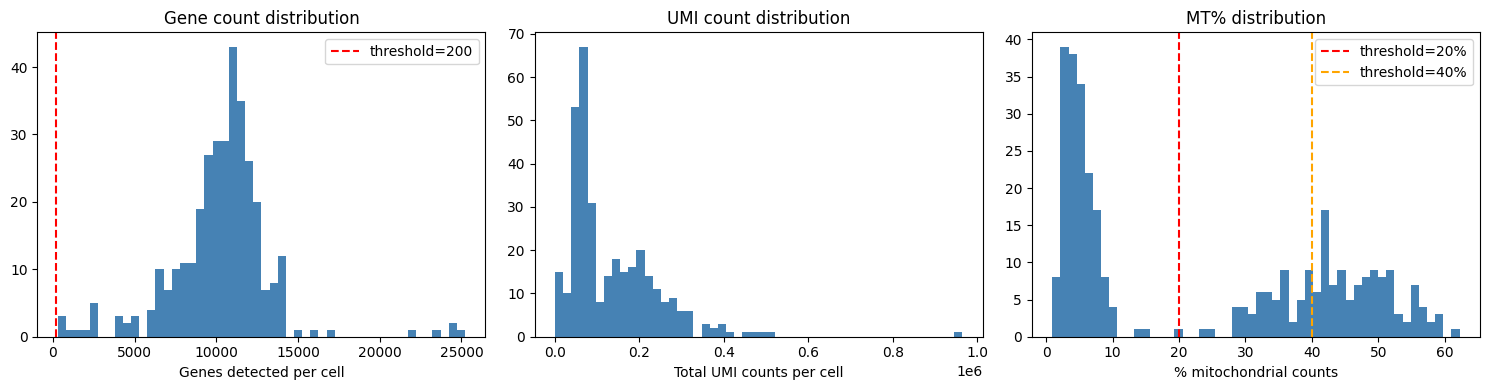


n_genes_by_counts:
  min=289.0, median=10671.0, max=25222.0
  10th pct=6860.8, 90th pct=12854.8

total_counts:
  min=392.1, median=85699.4, max=964756.2
  10th pct=44577.5, 90th pct=271630.5

pct_counts_mt:
  min=0.9, median=10.0, max=62.2
  10th pct=3.1, 90th pct=51.0


In [ ]:
# Visualize original data distribution
import matplotlib.pyplot as plt
# import scanpy as sc


# Annotate mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Plot distributions of all three key QC metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs['n_genes_by_counts'], bins=50, color='steelblue')
axes[0].set_xlabel('Genes detected per cell')
axes[0].set_title('Gene count distribution')
axes[0].axvline(200, color='red', linestyle='--', label='threshold=200')
axes[0].legend()

axes[1].hist(adata.obs['total_counts'], bins=50, color='steelblue')
axes[1].set_xlabel('Total UMI counts per cell')
axes[1].set_title('UMI count distribution')

axes[2].hist(adata.obs['pct_counts_mt'], bins=50, color='steelblue')
axes[2].set_xlabel('% mitochondrial counts')
axes[2].set_title('MT% distribution')
axes[2].axvline(20, color='red', linestyle='--', label='threshold=20%')
axes[2].axvline(40, color='orange', linestyle='--', label='threshold=40%')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print exact percentile values to inform threshold choice
# import numpy as np
for metric in ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']:
    vals = adata.obs[metric]
    print(f"\n{metric}:")
    print(f"  min={vals.min():.1f}, median={vals.median():.1f}, "
          f"max={vals.max():.1f}")
    print(f"  10th pct={np.percentile(vals,10):.1f}, "
          f"90th pct={np.percentile(vals,90):.1f}")

In [13]:
# Claude suggested QC Pipeline:
from scipy.stats import median_abs_deviation

adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

print(f"Starting cells: {adata.n_obs}")

# --- Filter 1: Remove cells with very few genes (true empty droplets/debris) ---
# Your min is 289, median is 10671 — only remove extreme low outliers
min_gene_threshold = 500   # safely below your 10th percentile of 6860
adata = adata[adata.obs['n_genes_by_counts'] >= min_gene_threshold].copy()
print(f"After gene filter (>={min_gene_threshold} genes): {adata.n_obs} cells")

# --- Filter 2: MT% — use MAD-based upper bound, not a fixed threshold ---
# Given your distribution, a fixed threshold is inappropriate
mt_vals = adata.obs['pct_counts_mt'].values
mt_median = np.median(mt_vals)
mt_mad = median_abs_deviation(mt_vals)
mt_upper = mt_median + 3 * mt_mad    # adaptive upper bound

print(f"\nMT% median: {mt_median:.1f}%, MAD: {mt_mad:.1f}%")
print(f"Adaptive MT upper threshold (median + 3 MAD): {mt_upper:.1f}%")

adata = adata[adata.obs['pct_counts_mt'] <= mt_upper].copy()
print(f"After adaptive MT filter (<={mt_upper:.1f}%): {adata.n_obs} cells")

# --- Filter 3: Remove genes detected in fewer than 3 cells ---
sc.pp.filter_genes(adata, min_cells=3)
print(f"After gene-level filter: {adata.n_obs} cells, {adata.n_vars} genes")


# NEXT STEPS
## we need more data that has RNA-seq by individual cell type. It doesn't necessarily need to be by single cell, but cell type.
## Once we collect other data from additional sources, we can amalgamate this to train AG on this and evaluate.

Starting cells: 335
After gene filter (>=500 genes): 333 cells

MT% median: 10.0%, MAD: 8.7%
Adaptive MT upper threshold (median + 3 MAD): 36.0%
After adaptive MT filter (<=36.0%): 207 cells
After gene-level filter: 207 cells, 48271 genes


In [14]:

# Store raw counts — scVI requires raw unnormalized counts
adata.layers["counts"] = adata.X.copy()

# Normalize and log-transform for visualization only (not for scVI input)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer="counts", flavor="seurat_v3") # can do 2000-3000
print(f"Highly variable genes selected: {adata.var['highly_variable'].sum()}")


/tmp/ipykernel_7174/767487060.py:7: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer="counts", flavor="seurat_v3") # can do 2000-3000


Highly variable genes selected: 2000


In [15]:
# Quality-controlled data size
print(f"Cells: {adata.n_obs}") #335 cells
print(f"Genes: {adata.n_vars}") #56594 genes
print(adata)

Cells: 207
Genes: 48271
AnnData object with n_obs × n_vars = 207 × 48271
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


## 5b. Train scVI and extract 14-dimensional cell embeddings

In [16]:
# Set up scVI model
# (n_cells × 14) maps to scVI's latent dimensionality
# Disable early stopping

# Claude corrected code

# Set up scVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key=None
)

model = scvi.model.SCVI(
    adata,
    n_latent=14,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb",
    dropout_rate=0.1       # add dropout for regularization — important with 207 cells
)

model.train(
    max_epochs=400,
    early_stopping=True,           # keep this on
    early_stopping_patience=30,    # generous patience — allow 30 epochs without improvement
    early_stopping_monitor="elbo_validation",
    batch_size=64,                 # stable gradient estimates for 207 cells; 64-128 is appropriate
    plan_kwargs={"lr": 1e-3}
)

# Get embeddings
cell_emb = model.get_latent_representation()
adata.obsm["X_scVI"] = cell_emb

print(f"Embedding shape: {cell_emb.shape}")
print(f"Training stopped at epoch: {model.history['elbo_train'].shape[0]}")
print(f"Variance per latent dim: {np.var(cell_emb, axis=0).round(4)}")

# Save
# model.save(
#     "/content/drive/MyDrive/MIT HST 506/scONEseq_data/scvi_model/",
#     overwrite=True
# )
# np.save(
#     "/content/drive/MyDrive/MIT HST 506/scONEseq_data/scvi_model/cell_embeddings_14d.npy",
#     cell_emb
# )

NameError: name 'scvi' is not defined

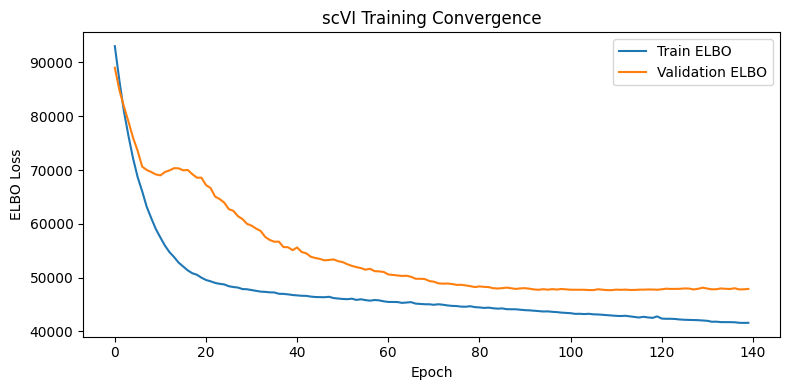

In [ ]:
import matplotlib.pyplot as plt

train_loss = model.history["elbo_train"]
val_loss   = model.history["elbo_validation"]

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label="Train ELBO")
plt.plot(val_loss,   label="Validation ELBO")
plt.xlabel("Epoch")
plt.ylabel("ELBO Loss")
plt.title("scVI Training Convergence")
plt.legend()
plt.tight_layout()
plt.show()

## 5c. Visualize and annotate cell types

Confirm the embeddings produce meaningful cell type clusters.
Annotate clusters with known marker genes or use automated tools like celltypist.
These cluster labels will become your ground truth cell type assignments for validating that your decoder learns cell-type-specific predictions.

/tmp/ipykernel_3518/1605474266.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)    # cluster labels


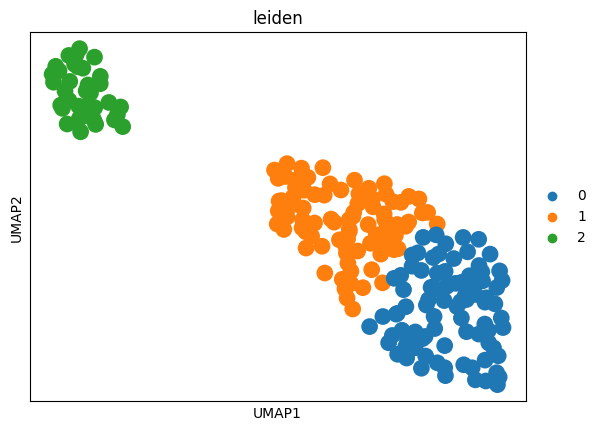

In [ ]:
# Use scVI embeddings for UMAP
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)    # cluster labels

sc.pl.umap(adata, color=["leiden"])    # inspect clusters

In [17]:
# Sanity check
print(adata.obs.columns.tolist())   # see what annotation columns exist
print(adata.obs['leiden'].value_counts())  # check if leiden clusters were assigned

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']


KeyError: 'leiden'

# 6. Generate DNA Sequence Embeddings (WGS Input)

## 6a. Align raw WGS FASTQs to reference genome

If working with raw FASTQs from SRA, you need to align them first. This is a compute-heavy step best run outside Colab (on a cluster or cloud VM), but the logic is:


In [ ]:
%%bash

# Align each cell's WGS FASTQ to GRCh38
bwa mem -t 8 GRCh38.fa {cell}_dna_1.fastq.gz {cell}_dna_2.fastq.gz \
  | samtools sort -o {cell}.bam
samtools index {cell}.bam

In [ ]:
# Download the reference genome

ref_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/reference"
os.makedirs(ref_dir, exist_ok=True)

# Download GRCh38 reference genome (this is large — ~1GB compressed)
!wget -q -P "{ref_dir}" \
    https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz

# Decompress
!gunzip "{ref_dir}/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz"

REF = f"{ref_dir}/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna"
print(f"Reference genome saved to: {REF}")

Reference genome saved to: /content/drive/MyDrive/MIT HST 506/scONEseq_data/reference/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna


In [ ]:
# Install Alignment Tools
# BWA for alignment, samtools for BAM processing
!apt-get install -y -qq bwa samtools

# Verify
!bwa 2>&1 | head -3
!samtools --version | head -1


Selecting previously unselected package bwa.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../bwa_0.7.17-6_amd64.deb ...
Unpacking bwa (0.7.17-6) ...
Selecting previously unselected package libhtscodecs2:amd64.
Preparing to unpack .../libhtscodecs2_1.1.1-3_amd64.deb ...
Unpacking libhtscodecs2:amd64 (1.1.1-3) ...
Selecting previously unselected package libhts3:amd64.
Preparing to unpack .../libhts3_1.13+ds-2build1_amd64.deb ...
Unpacking libhts3:amd64 (1.13+ds-2build1) ...
Selecting previously unselected package samtools.
Preparing to unpack .../samtools_1.13-4_amd64.deb ...
Unpacking samtools (1.13-4) ...
Setting up libhtscodecs2:amd64 (1.1.1-3) ...
Setting up libhts3:amd64 (1.13+ds-2build1) ...
Setting up bwa (0.7.17-6) ...
Setting up samtools (1.13-4) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symb

In [ ]:
# Index the reference genome (run once, save index to Drive)
index_flag = f"{ref_dir}/bwa_index.done"

if not os.path.exists(index_flag):
    print("Building BWA index — this takes ~60-90 minutes...")
    !bwa index "{REF}"
    !touch "{index_flag}"
    print("Index complete.")
else:
    print("BWA index already exists, skipping.")


Building BWA index — this takes ~60-90 minutes...
[bwa_index] Pack FASTA... 21.31 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=6199845082, availableWord=448243540
[BWTIncConstructFromPacked] 10 iterations done. 99999994 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 199999994 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 299999994 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 399999994 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 499999994 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 599999994 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 699999994 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 799999994 characters processed.
[BWTIncConstructFromPacked] 90 iterations done. 899999994 characters processed.
[BWTIncConstructFromPacked] 100 iterations done. 999999994 characters processed.

In [ ]:
# Confirm you have BWA index files
# List all files in your reference directory with sizes
print(f"Contents of: {ref_dir}\n")
for f in sorted(os.listdir(ref_dir)):
    size_gb = os.path.getsize(os.path.join(ref_dir, f)) / 1e9
    print(f"  {f:60s}  {size_gb:.2f} GB")

Contents of: /content/drive/MyDrive/MIT HST 506/scONEseq_data/reference

  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna               3.14 GB
  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.amb           0.00 GB
  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.ann           0.00 GB
  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.bwt           3.10 GB
  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.pac           0.77 GB
  GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.sa            1.55 GB
  bwa_index.done                                                0.00 GB


In [ ]:
# Authenticate with Google Cloud from Colab
from google.colab import auth
auth.authenticate_user()

# Upload reference genome and BWA index files to GCS
bucket = "storage-bucket-alignment-results"

# Upload all reference files
ref_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/reference"
!gsutil -m cp "{ref_dir}/"* gs://{bucket}/reference/

# Upload your SRR accession list
srr_list_path = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_SRR_List.txt"
!gsutil cp "{srr_list_path}" gs://{bucket}/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///content/drive/MyDrive/MIT HST 506/scONEseq_data/reference/bwa_index.done [Content-Type=application/octet-stream]...
Copying file:///content/drive/MyDrive/MIT HST 506/scONEseq_data/reference/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.amb [Content-Type=application/octet-stream]...
Copying file:///content/drive/MyDrive/MIT HST 506/scONEseq_data/reference/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.ann [Content-Type=application/octet-stream]...
Copying file:///content/drive/MyDrive/MIT HST 506/scONEseq_data/reference/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.pac [Content-Type=application/x-ns-proxy-autoconfig]...
==> NOTE: You are uploading one or more large file(s), which would run          
significantl

In [ ]:
# Upload your SRR accession list
srr_list_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/lists"
!gsutil -m cp "{srr_list_dir}" gs://{bucket}/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Omitting directory "file:///content/drive/MyDrive/MIT HST 506/scONEseq_data/lists". (Did you mean to do cp -r?)
CommandException: No URLs matched. Do the files you're operating on exist?


In [ ]:
# Align each cell's DNA FASTQs
# For each cell, align the paired-end WGS FASTQs to GRCh38:

CELL_ID = 1
DNA_SRR = "SRR16195157"
#SRR16195157_1.fastq.gz

bam_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files"
fastq_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files/dna"

fq1  = f"{fastq_dir}/{DNA_SRR}_1.fastq.gz"
fq2  = f"{fastq_dir}/{DNA_SRR}_2.fastq.gz"
bam  = f"{bam_dir}/{CELL_ID}.bam"
done = f"{bam_dir}/{CELL_ID}.done"

if os.path.exists(done):
    print(f"Skipping {CELL_ID} — already aligned")

print(f"Aligning {CELL_ID} ({DNA_SRR})...")

# Align with BWA-MEM, add read group tag for cell identity
!bwa mem -t 4 \
    -R "@RG\tID:{CELL_ID}\tSM:{CELL_ID}\tPL:ILLUMINA" \
    "{REF}" "{fq1}" "{fq2}" \
    | samtools sort -@ 4 -o "{bam}"

# Index the BAM
!samtools index "{bam}"

# Mark as done
!touch "{done}"

# Quick QC check
!samtools flagstat "{bam}" | grep "mapped ("

print("Alignment complete for all cells.")

Skipping 1 — already aligned
Aligning 1 (SRR16195157)...
[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 558482 sequences (40000120 bp)...
[M::process] read 558490 sequences (40000001 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (1545, 137800, 1174, 1136)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (63, 116, 224)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 546)
[M::mem_pestat] mean and std.dev: (123.97, 95.28)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 707)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (145, 192, 257)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 481)
[M::mem_pestat] mean and std.dev: (194.93, 73.60)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 593)
[M::mem_pestat] analyzing insert size distribut

In [ ]:
# Align each cell's DNA FASTQs
# For each cell, align the paired-end WGS FASTQs to GRCh38:


# Load your cell pairing table (cell ID, DNA SRR, RNA SRR)
cell_table = pd.read_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/DNA_RNA_pairs.csv")

bam_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files"
fastq_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files/dna"
os.makedirs(bam_dir, exist_ok=True)

for _, row in cell_table.iterrows():
    cell_id = row['cell_num']
    srr     = row['dna_run']

    fq1  = f"{fastq_dir}/{srr}_1.fastq.gz"
    fq2  = f"{fastq_dir}/{srr}_2.fastq.gz"
    bam  = f"{bam_dir}/{cell_id}.bam"
    done = f"{bam_dir}/{cell_id}.done"

    if os.path.exists(done):
        print(f"Skipping {cell_id} — already aligned")
        continue

    print(f"Aligning {cell_id} ({srr})...")

    # Align with BWA-MEM, add read group tag for cell identity
    !bwa mem -t 4 \
        -R "@RG\tID:{cell_id}\tSM:{cell_id}\tPL:ILLUMINA" \
        "{REF}" "{fq1}" "{fq2}" \
        | samtools sort -@ 4 -o "{bam}"

    # Index the BAM
    !samtools index "{bam}"

    # Mark as done
    !touch "{done}"

    # Quick QC check
    !samtools flagstat "{bam}" | grep "mapped ("

print("Alignment complete for all cells.")

Aligning 1 (SRR22047575)...
[M::bwa_idx_load_from_disk] read 0 ALT contigs
[E::main_mem] fail to open file `/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files/dna/SRR22047575_1.fastq.gz'.
samtools sort: failed to read header from "-"
[E::hts_open_format] Failed to open file "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files/1.bam" : No such file or directory
samtools index: failed to open "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files/1.bam": No such file or directory
[E::hts_open_format] Failed to open file "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files/1.bam" : No such file or directory
samtools flagstat: Cannot open input file "/content/drive/MyDrive/MIT HST 506/scONEseq_data/bam_files/1.bam": No such file or directory
Aligning 2 (SRR22047574)...
[M::bwa_idx_load_from_disk] read 0 ALT contigs
[E::main_mem] fail to open file `/content/drive/MyDrive/MIT HST 506/scONEseq_data/FASTQ_files/dna/SRR22047574_1.fastq.gz'.
samtools sort: failed to 

In [ ]:
# Assess coverage per cell -- tells you what variant calling is feasible

coverage_stats = []

for _, row in cell_table.iterrows():
    cell_id = row['cell_id']
    bam = f"{bam_dir}/{cell_id}.bam"

    # Get mean coverage depth across genome
    result = !samtools depth -a "{bam}" | awk '{{sum+=$3}} END {{print sum/NR}}'
    mean_cov = float(result[0]) if result else 0.0
    coverage_stats.append({'cell_id': cell_id, 'mean_coverage': mean_cov})
    print(f"{cell_id}: {mean_cov:.4f}x mean coverage")

cov_df = pd.DataFrame(coverage_stats)
print(f"\nMedian coverage across cells: {cov_df['mean_coverage'].median():.4f}x")
print(f"Min: {cov_df['mean_coverage'].min():.4f}x")
print(f"Max: {cov_df['mean_coverage'].max():.4f}x")

cov_df.to_csv("/content/drive/MyDrive/MIT HST 506/scONEseq_data/coverage_stats.csv", index=False)



## 6b. Define 1 Mb genomic windows

AlphaGenome operates on fixed 1 Mb windows. You need to define which windows are relevant to your cells — typically centered on gene-dense regions or exons captured in your RNA-seq data:

In [18]:
import pyranges as pr

# Define 1 Mb tiling windows across the genome
# Or focus on windows overlapping expressed genes
expressed_genes = adata.var_names[adata.var['highly_variable']]

# Load GTF gene annotations and extract coordinates for expressed genes
# Then create 1Mb windows centered on each gene locus

In [19]:
# Window Selection
import pyranges as pr

ref_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/reference"


# Download GTF gene annotation for GRCh38
gtf_path = f"{ref_dir}/gencode.v44.basic.annotation.gtf.gz"
!wget -q -P "{ref_dir}" \
    https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.basic.annotation.gtf.gz

# Load GTF and extract gene coordinates
gtf = pr.read_gtf(gtf_path)
genes = gtf[gtf.Feature == "gene"][["Chromosome", "Start", "End", "gene_name"]]

# Filter to highly variable genes from your scVI/scanpy analysis
# (adata.var_names[adata.var['highly_variable']] from Phase 1)
hvg_names = list(adata.var_names[adata.var['highly_variable']])
hvg_genes  = genes[genes.gene_name.isin(hvg_names)]

print(f"Highly variable genes with genomic coordinates: {len(hvg_genes)}")

Highly variable genes with genomic coordinates: 1639


In [20]:
# Create 1 Mb windows centered on HVGs

# Chromosome sizes for GRCh38
chrom_sizes = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
    'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
    'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
    'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
    'chr16': 90338345,  'chr17': 83257441,  'chr18': 80373285,
    'chr19': 58617616,  'chr20': 64444167,  'chr21': 46709983,
    'chr22': 50818468,  'chrX': 156040895,  'chrY': 57227415
}

WINDOW_SIZE = 1_000_000   # 1 Mb

windows = []
seen = set()   # deduplicate overlapping windows

for _, gene in hvg_genes.df.iterrows():
    chrom = gene['Chromosome']
    if chrom not in chrom_sizes:
        continue

    # Center 1 Mb window on gene midpoint
    midpoint = (gene['Start'] + gene['End']) // 2
    win_start = max(0, midpoint - WINDOW_SIZE // 2)
    win_end   = min(chrom_sizes[chrom], win_start + WINDOW_SIZE)
    win_start = win_end - WINDOW_SIZE   # adjust start if end was clipped

    # Create a unique key to avoid redundant overlapping windows
    win_key = f"{chrom}:{win_start // 500_000}"   # 500 kb bins for deduplication
    if win_key in seen:
        continue
    seen.add(win_key)

    windows.append({
        'window_id': f"{chrom}_{win_start}_{win_end}",
        'chrom':     chrom,
        'start':     win_start,
        'end':       win_end,
        'gene_name': gene['gene_name']
    })

windows_df = pd.DataFrame(windows)
print(f"Total unique 1 Mb windows: {len(windows_df)}")
windows_df.to_csv(
    "/content/drive/MyDrive/MIT HST 506/scONEseq_data/genomic_windows.csv",
    index=False
)
windows_df.head(10)

Total unique 1 Mb windows: 1205


,window_id,chrom,start,end,gene_name
0,chr1_130161_1130161,chr1,130161,1130161,MTND2P28
1,chr1_5546059_6546059,chr1,5546059,6546059,KCNAB2
2,chr1_11245442_12245442,chr1,11245442,12245442,AGTRAP
3,chr1_12630216_13630216,chr1,12630216,13630216,PRAMEF36P
4,chr1_15160872_16160872,chr1,15160872,16160872,RSC1A1
5,chr1_15875359_16875359,chr1,15875359,16875359,SZRD1
6,chr1_17983451_18983451,chr1,17983451,18983451,KLHDC7A
7,chr1_19127717_20127717,chr1,19127717,20127717,NBL1
8,chr1_21043903_22043903,chr1,21043903,22043903,ALPL
9,chr1_21979997_22979997,chr1,21979997,22979997,ZBTB40


In [22]:
# Extract DNA Sequences for each window

from pyfaidx import Fasta

ref_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/reference"
REF = f"{ref_dir}/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna"

# Load reference genome for fast sequence extraction
ref_genome = Fasta(REF)

seq_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/window_sequences"
os.makedirs(seq_dir, exist_ok=True)

window_sequences = {}

for _, win in windows_df.iterrows():
    wid   = win['window_id']
    chrom = win['chrom']
    start = int(win['start'])
    end   = int(win['end'])

    # Extract sequence (pyfaidx is 0-indexed, end-exclusive)
    seq = str(ref_genome[chrom][start:end]).upper()

    # Verify length
    assert len(seq) == WINDOW_SIZE, f"Window {wid} has length {len(seq)}, expected {WINDOW_SIZE}"

    # Replace any N-runs with a flag for downstream handling
    n_fraction = seq.count('N') / len(seq)
    if n_fraction > 0.1:
        print(f"Warning: window {wid} has {n_fraction:.1%} N bases — consider skipping")

    window_sequences[wid] = seq

print(f"Sequences extracted for {len(window_sequences)} windows")

# Save sequences
import pickle
with open(f"{seq_dir}/window_sequences.pkl", "wb") as f:
    pickle.dump(window_sequences, f)



Sequences extracted for 1205 windows


## 6c. Extract per-cell variant calls

Since scONE-seq produces sparse WGS coverage, extract per-cell variants (SNPs, CNVs) to overlay on the reference:

In [ ]:
# For each cell BAM, call variants relative to GRCh38
# Use GATK HaplotypeCaller or bcftools for SNP calls
# Use CNVkit or HMMcopy for CNV calls from sparse coverage

# The reference genome + per-cell variant overlay = your model's DNA input

In [23]:
# Bin Read counts across the genome
# Install CNV calling tools
!pip install -q cnvpytor

import cnvpytor


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.6/700.6 kB 55.6 MB/s eta 0:00:00


In [ ]:
# Call CNVs per cell using CNVpytor
cnv_dir = "/content/drive/MyDrive/MIT HST 506/scONEseq_data/cnv_calls"
os.makedirs(cnv_dir, exist_ok=True)

# Bin size: 100kb is appropriate for 0.05x coverage
# Smaller bins have too few reads per bin at this depth
BIN_SIZE = 100_000

for _, row in cell_table.iterrows():
    cell_id = row['cell_id']
    bam     = f"{bam_dir}/{cell_id}.bam"
    pytor   = f"{cnv_dir}/{cell_id}.pytor"
    done    = f"{cnv_dir}/{cell_id}.done"

    if os.path.exists(done):
        print(f"Skipping {cell_id} — CNVs already called")
        continue

    print(f"Calling CNVs for {cell_id}...")

    # Create pytor file and import read depth
    !cnvpytor -root "{pytor}" -rd "{bam}"

    # Calculate read depth histograms
    !cnvpytor -root "{pytor}" -his {BIN_SIZE}

    # Calculate statistics
    !cnvpytor -root "{pytor}" -stat {BIN_SIZE}

    # Partition into CNV segments
    !cnvpytor -root "{pytor}" -partition {BIN_SIZE}

    # Call CNVs and export to TSV
    !cnvpytor -root "{pytor}" -call {BIN_SIZE} > "{cnv_dir}/{cell_id}_cnv_calls.tsv"

    !touch "{done}"
    print(f"CNV calling complete for {cell_id}")

print("CNV calling complete.")


In [ ]:
# Parse CNV Calls into a per-cell per-window matrix
# converts raw CNV calls into a format needed for the model- CN value for each genome window for each cell

def parse_cnvpytor_output(cnv_file):
    """Parse CNVpytor output into a DataFrame of CNV segments."""
    cols = ['type', 'chrom_start', 'length', 'cn_normalized',
            'e_val1', 'e_val2', 'e_val3', 'e_val4', 'q0']
    try:
        df = pd.read_csv(cnv_file, sep='\t', names=cols, comment='#')
        # Parse chrom and start from "chr1:1000000" format
        df[['chrom', 'start']] = df['chrom_start'].str.split(':', expand=True)
        df['start'] = df['start'].astype(int)
        df['end']   = df['start'] + df['length']
        return df
    except Exception as e:
        print(f"Error parsing {cnv_file}: {e}")
        return pd.DataFrame()


def get_copy_number_for_window(cnv_df, chrom, win_start, win_end):
    """
    Get the copy number state overlapping a genomic window.
    Returns 2.0 (diploid) if no CNV call overlaps.
    """
    if cnv_df.empty:
        return 2.0

    overlapping = cnv_df[
        (cnv_df['chrom'] == chrom) &
        (cnv_df['start'] < win_end) &
        (cnv_df['end']   > win_start)
    ]

    if overlapping.empty:
        return 2.0   # diploid default

    # Weight by overlap fraction
    total_overlap = 0
    weighted_cn   = 0
    for _, seg in overlapping.iterrows():
        overlap = min(seg['end'], win_end) - max(seg['start'], win_start)
        total_overlap += overlap
        weighted_cn   += float(seg['cn_normalized']) * overlap

    return weighted_cn / total_overlap if total_overlap > 0 else 2.0


# Build (n_cells x n_windows) copy number matrix
cn_matrix = pd.DataFrame(
    index=cell_table['cell_id'],
    columns=windows_df['window_id'],
    dtype=float
)

for _, row in cell_table.iterrows():
    cell_id  = row['cell_id']
    cnv_file = f"{cnv_dir}/{cell_id}_cnv_calls.tsv"
    cnv_df   = parse_cnvpytor_output(cnv_file)

    for _, win in windows_df.iterrows():
        cn = get_copy_number_for_window(
            cnv_df, win['chrom'], int(win['start']), int(win['end'])
        )
        cn_matrix.loc[cell_id, win['window_id']] = cn

print(f"Copy number matrix shape: {cn_matrix.shape}")
print(f"  Rows: {cn_matrix.shape[0]} cells")
print(f"  Cols: {cn_matrix.shape[1]} windows")
print(f"\nCopy number distribution:")
print(cn_matrix.values.flatten())

cn_matrix.to_csv(
    "/content/drive/MyDrive/MIT HST 506/scONEseq_data/copy_number_matrix.csv"
)



# 7. Implement the AlphaGenome API and Extract Sequence Embeddings

## 7a. Query AlphaGenome for Sequence Embeddings

In [ ]:
import alphagenome
from alphagenome.models import dna_client

# Initialize the API
client = dna_client.DnaClient()

# For each 1Mb window, get the sequence embedding
# seq_emb shape: (1_000_000 × 667) — one value per position per RNA-seq track
sequence_embeddings = {}

for window_id, (chrom, start, end, sequence) in genomic_windows.items():
    output = client.predict(
        sequence=sequence,           # 1Mb DNA string (A/T/G/C)
        organism="human"
    )
    sequence_embeddings[window_id] = output.embeddings   # (positions × 667)

import pickle
with open("sequence_embeddings.pkl", "wb") as f:
    pickle.dump(sequence_embeddings, f)

## 7b. Align RNA-seq Coverage Tracks to AlphaGenome Output Positions
Your decoder predicts RNA-seq coverage at exon positions. You need ground truth coverage from your scRNA-seq data to supervise training:

In [ ]:
# For each cell, extract per-exon read coverage from RNA-seq BAM
# This becomes your training target: (n_cells × exon_positions)
# The squashed scale in your architecture likely refers to log1p or sqrt transform

# 8. Implement the CellSpecificDecoder

In [ ]:
import torch
import torch.nn as nn

class HypernetworkMLP(nn.Module):
    """
    Takes a 14-dim cell embedding and produces weights/biases
    that modulate the 667-track AlphaGenome output.
    Architecture: 14 → 64 → 128 → 256 → (667+1)
    """
    def __init__(self, cell_emb_dim=14, n_tracks=667):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cell_emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, n_tracks + 1)   # 667 scale factors + 1 bias
        )

    def forward(self, cell_emb):
        # cell_emb: (batch_size, 14)
        return self.net(cell_emb)          # (batch_size, 668)


class CellSpecificDecoder(nn.Module):
    """
    Modulates AlphaGenome sequence embeddings with cell-specific weights.
    """
    def __init__(self, cell_emb_dim=14, n_tracks=667):
        super().__init__()
        self.hypernetwork = HypernetworkMLP(cell_emb_dim, n_tracks)

    def forward(self, seq_emb, cell_emb):
        # seq_emb:  (batch, positions, 667) — from AlphaGenome API
        # cell_emb: (batch, 14)             — from scVI

        hyper_out = self.hypernetwork(cell_emb)     # (batch, 668)
        scale = hyper_out[:, :667].unsqueeze(1)     # (batch, 1, 667)
        bias  = hyper_out[:, 667:].unsqueeze(1)     # (batch, 1, 1)

        # Element-wise modulation of sequence embedding
        modulated = seq_emb * scale + bias          # (batch, positions, 667)

        # Aggregate over tracks to predict per-position coverage
        predicted_coverage = modulated.mean(dim=-1) # (batch, positions)
        predicted_coverage = torch.log1p(
            torch.relu(predicted_coverage)
        )                                           # squashed scale

        return predicted_coverage

# 9. Training Loop

In [ ]:
from torch.utils.data import DataLoader, Dataset

class SingleCellGenomicsDataset(Dataset):
    def __init__(self, cell_ids, cell_embeddings, sequence_embeddings, coverage_targets):
        self.cell_ids = cell_ids
        self.cell_emb = torch.tensor(cell_embeddings, dtype=torch.float32)
        self.seq_emb = sequence_embeddings    # dict: cell_id → tensor
        self.targets = coverage_targets       # dict: cell_id → tensor

    def __len__(self):
        return len(self.cell_ids)

    def __getitem__(self, idx):
        cid = self.cell_ids[idx]
        return self.cell_emb[idx], self.seq_emb[cid], self.targets[cid]


# Training
decoder = CellSpecificDecoder()
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-4)
loss_fn = nn.PoissonNLLLoss(log_input=True)   # appropriate for count data

for epoch in range(100):
    for cell_emb, seq_emb, target in dataloader:
        optimizer.zero_grad()
        pred = decoder(seq_emb, cell_emb)
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")